# Telco Customer Churn Analysis
### IBM Telco Dataset — Exploratory Data Analysis & Predictive Modeling

**Author:** Caio Tormin  
**Date:** March 2026  
**Assisted by:** [Claude](https://claude.ai) (Anthropic)

---

## Introduction

Customer churn — when a subscriber cancels their service — is one of the costliest challenges in the telecommunications industry. Acquiring a new customer is significantly more expensive than retaining an existing one, making churn prediction a high-value business problem.

This notebook analyzes the **IBM Telco Customer Churn** dataset, which contains information on 7,043 California-based customers including demographics, account details, services subscribed, and whether each customer churned.

The analysis is structured in two parts:

1. **Exploratory Data Analysis (EDA)** — understanding the geographical distribution of customers, the relationship between contract type and churn, the role of internet service, and how monthly charges differ between churners and retained customers.
2. **Predictive Modeling** — a `DecisionTreeClassifier` trained to identify customers at risk of churning, evaluated with an 80/20 stratified split and 5-fold cross-validation.

## Dataset

**Source:** [IBM Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset)  
**Format:** Excel (.xlsx) · 7,043 rows × 33 columns

Each row represents one unique customer. The columns fall into five groups:

| Group | Features |
|---|---|
| **Location** | City, State, Zip Code, Latitude, Longitude |
| **Demographics** | Gender, Senior Citizen, Partner, Dependents |
| **Account** | Tenure (months), Contract type, Paperless Billing, Payment Method, Monthly Charges, Total Charges, CLTV |
| **Services** | Phone, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies |
| **Churn** | Churn Label (Yes/No), Churn Value (0/1), Churn Score, Churn Reason |

### Key facts
- **~26.5% churn rate** — the dataset is moderately imbalanced (~73% No / ~27% Yes)
- **Month-to-month contracts** account for the majority of churners
- **Fiber optic** internet subscribers churn at a higher rate than DSL or no-internet customers
- **Churn Reason** is only populated for customers who churned; the most common reasons are competitor offers and relocation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



In [2]:
%pip install kagglehub openpyxl
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Telco_customer_churn.xlsx"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yeanzc/telco-customer-churn-ibm-dataset",
  file_path,
)

print("First 5 records:", df.head())

Note: you may need to restart the kernel to use updated packages.
First 5 records:    CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Mont

In [3]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


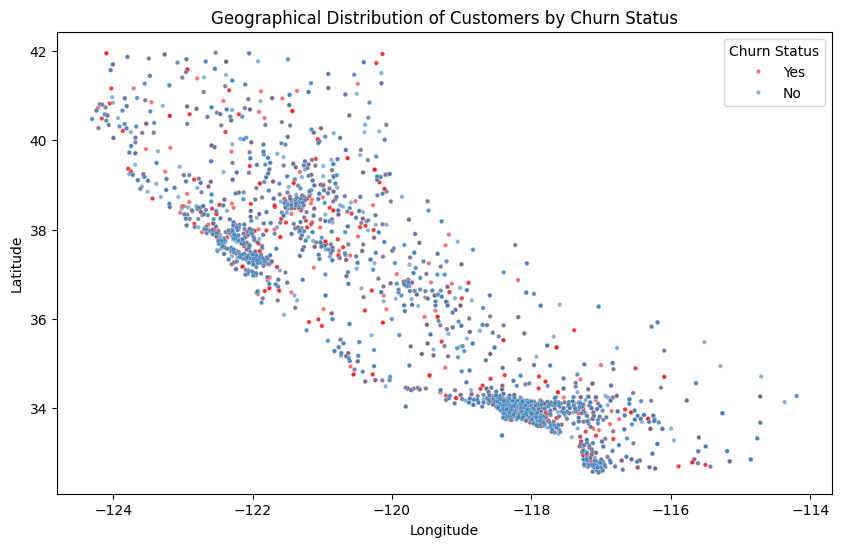

In [4]:
# scatter plot to visualize geographical distribution of customers; hue by churn status; only include month by month customers
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['Contract'] == 'Month-to-month'], x='Longitude', y='Latitude', hue='Churn Label', palette='Set1', alpha=0.6, edgecolor='w', s=10)
plt.title('Geographical Distribution of Customers by Churn Status')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Churn Status')
plt.show()

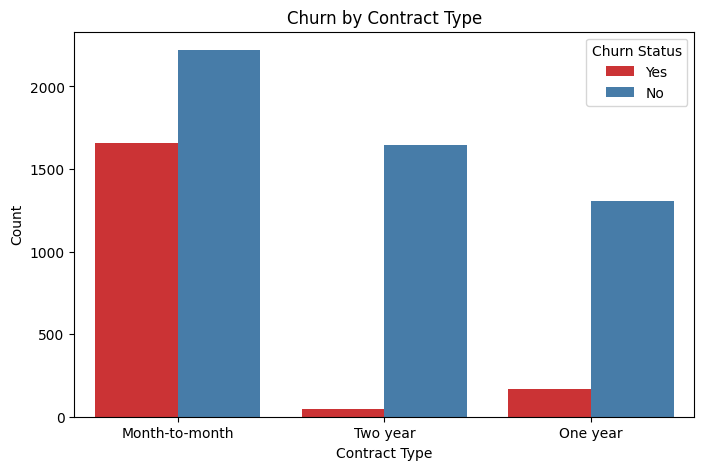

In [5]:
# churn by contract type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn Label', palette='Set1')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn Status')
plt.show()

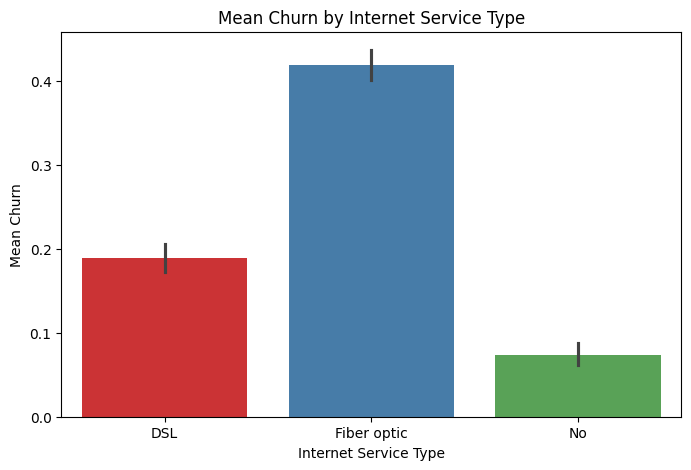

In [6]:
# visualize mean churn value by internet service type

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Internet Service', y='Churn Value', palette='Set1')
plt.title('Mean Churn by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Mean Churn')
plt.show()

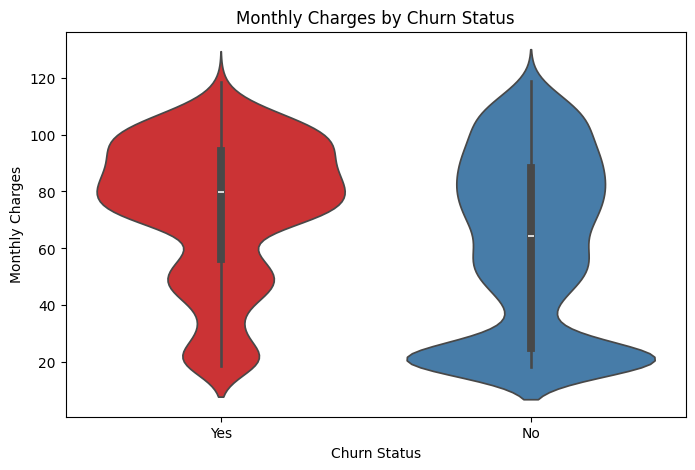

In [7]:
# boxplots to compare distribution of monthly charges by churn status
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Churn Label', y='Monthly Charges', palette='Set1')
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')
plt.show()  

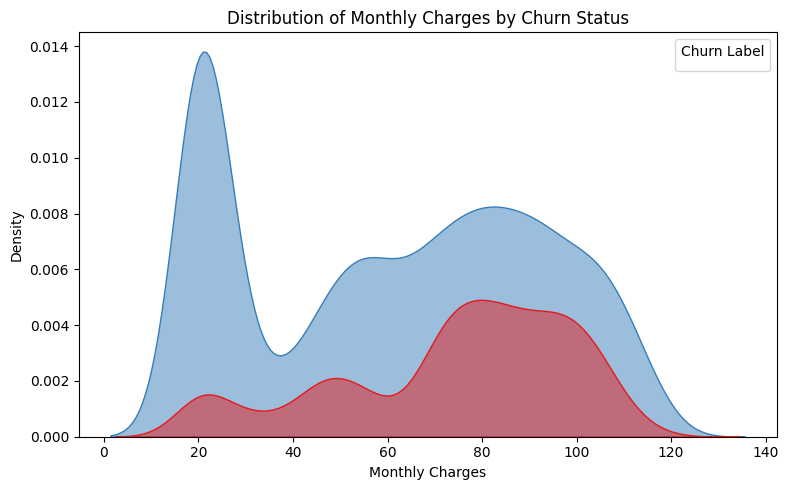

In [8]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Monthly Charges', hue='Churn Label', fill=True, palette='Set1', alpha=0.5)
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.legend(title='Churn Label')
plt.tight_layout()
plt.show()


## Modeling

A `DecisionTreeClassifier` trained on all 7,043 customers to predict **Churn Label** (Yes / No). `class_weight='balanced'` corrects for the class imbalance (~73% No / ~27% Yes). Evaluated with a stratified 80/20 split and 5-fold cross-validation.

In [9]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


Class distribution:
 Churn Label
No     5174
Yes    1869
Name: count, dtype: int64 

              precision    recall  f1-score   support

          No       0.90      0.75      0.82      1035
         Yes       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



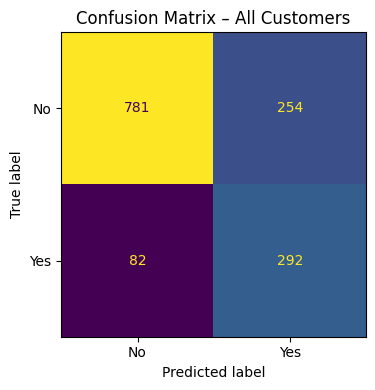

CV accuracy: 0.738 ± 0.015
CV f1_macro: 0.713 ± 0.010
CV recall_macro: 0.769 ± 0.008


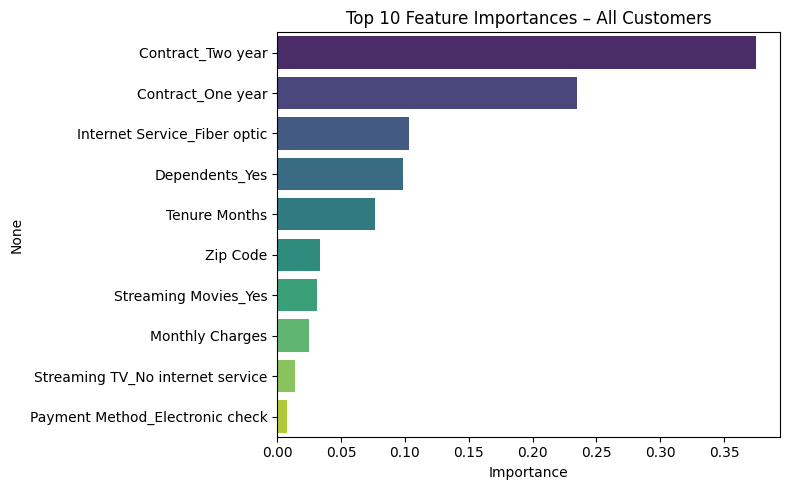

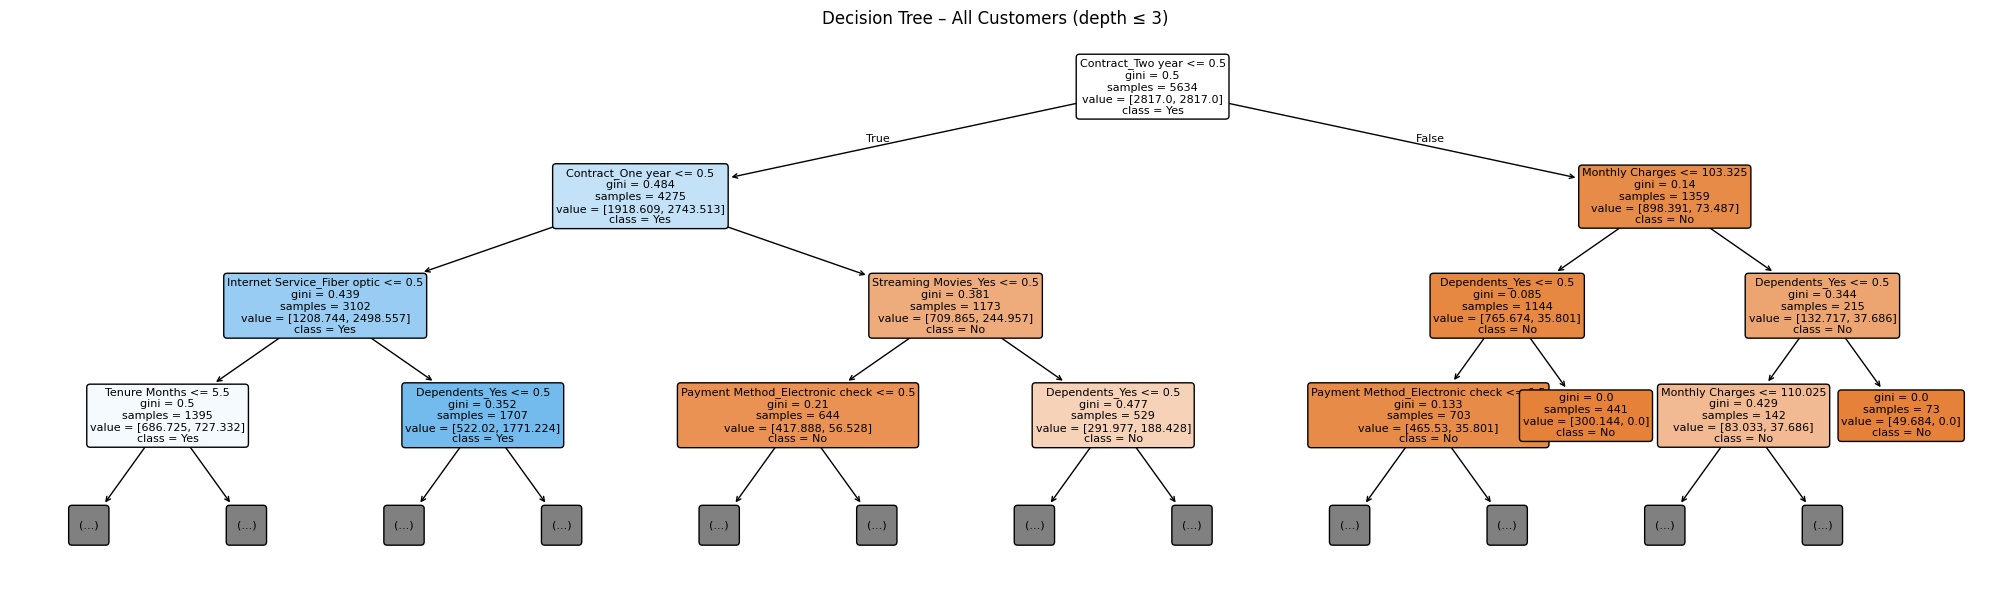

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# All customers
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'Lat Long',
    'Churn Score', 'Churn Value', 'Churn Reason', 'CLTV'
]
features = df.drop(columns=drop_cols + ['Churn Label'])
target = df['Churn Label']

print("Class distribution:\n", target.value_counts(), "\n")

# Encode categoricals and handle missing values
features = pd.get_dummies(features, drop_first=True)
features = features.fillna(features.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
plt.title('Confusion Matrix – All Customers')
plt.tight_layout()
plt.show()

# 5-Fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for metric in ('accuracy', 'f1_macro', 'recall_macro'):
    scores = cross_val_score(dt, features, target, cv=cv, scoring=metric)
    print(f"CV {metric}: {scores.mean():.3f} ± {scores.std():.3f}")

# Feature importances
importances = (
    pd.Series(dt.feature_importances_, index=features.columns)
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 10 Feature Importances – All Customers')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Tree diagram
plt.figure(figsize=(20, 6))
plot_tree(dt, max_depth=3, feature_names=features.columns.tolist(),
          class_names=dt.classes_.tolist(), filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree – All Customers (depth ≤ 3)')
plt.tight_layout()
plt.show()

## Decision Tree Results – All Customers (Class-Balanced)

With all contract types included, **Contract** becomes available as a feature and is expected to appear near the root — month-to-month customers churn at a far higher rate than one- or two-year customers, making it a strong early split. Tenure and Internet Service continue to drive splits below that.

### Node Colors
- **Orange** → majority class is **No** (not churning) — deeper = more confident
- **Blue** → majority class is **Yes** (churning) — deeper = more confident
- **Washed-out / white** → node is near 50/50 (high uncertainty). The root is near-white (Gini ≈ 0.5) because `class_weight='balanced'` equalises both classes going into training.

### Path Examples

**Example 1 — Very high churn risk** `→ Predicted: Yes`
> Month-to-month contract · fiber optic · tenure ≤ 1.5 months · high monthly charges.
> Brand-new high-spend subscriber still in the comparison-shopping window — the strongest churn signal in the data.

**Example 2 — High churn risk** `→ Predicted: Yes`
> Month-to-month contract · no fiber optic · tenure ≤ 5.5 months · no Tech Support.
> Short-tenure customer on a basic plan. No add-ons or long-term commitment create very low switching cost.

**Example 3 — Moderate churn risk** `→ Predicted: Yes`
> Month-to-month contract · fiber optic · tenure 1.5–13.5 months · no dependents.
> Past the first-month drop-off but still early-stage. Without family ties, price or service frustrations are enough to leave.

**Example 4 — Low churn risk** `→ Predicted: No`
> One-year contract · any internet service · tenure > 12 months.
> Contract commitment and established tenure create strong retention. Exit penalty removes impulsive churn.

**Example 5 — Very low churn risk** `→ Predicted: No`
> Two-year contract · any profile.
> Two-year customers almost never churn — the tree likely classifies this branch as No with very high confidence regardless of other features.

**Example 6 — Low churn risk** `→ Predicted: No`
> Month-to-month contract · fiber optic · tenure > 13.5 months · has dependents.
> Long-tenure family account on a flexible contract. Inertia and complexity of switching a family plan outweigh dissatisfaction.